## Rough Baseline Results Before Preprocessing

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
pr_auc = average_precision_score(y_test, y_prob)
print("PR-AUC:", pr_auc)

              precision    recall  f1-score   support

         0.0       0.85      0.94      0.89       388
         1.0       0.69      0.47      0.56       116

    accuracy                           0.83       504
   macro avg       0.77      0.70      0.73       504
weighted avg       0.82      0.83      0.82       504

ROC-AUC: 0.8276306434411662
PR-AUC: 0.6627816644225017


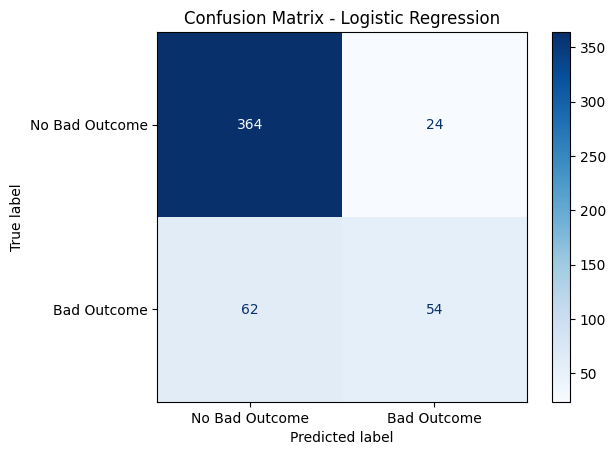

In [ ]:
# Output a confusion matrix to see performance
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=["No Bad Outcome", "Bad Outcome"],
    cmap=plt.cm.Blues)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

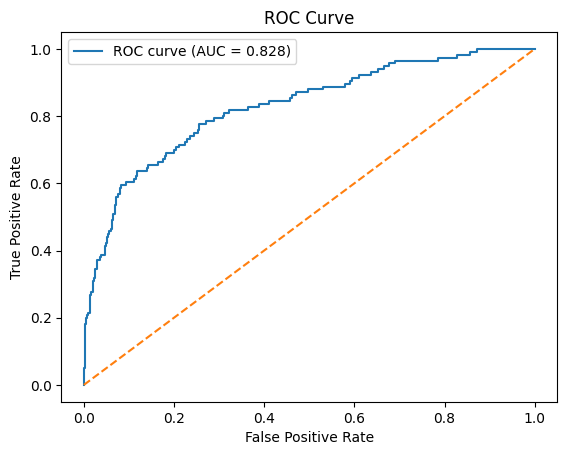

In [ ]:
# ROC-curve
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

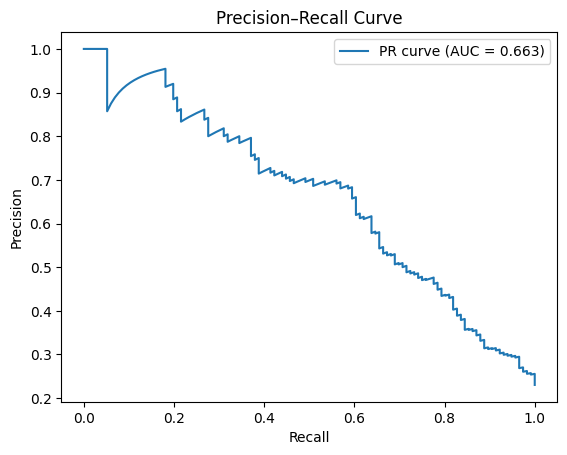

In [ ]:
# PR-AUC curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure()
plt.plot(recall, precision, label=f"PR curve (AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

| Class / Metric           | Precision | Recall | F1-score | Support |
| ------------------------ | --------- | ------ | -------- | ------- |
| **0.0 (No bad outcome)** | 0.86      | 0.94   | 0.90     | 388     |
| **1.0 (Bad outcome)**    | 0.72      | 0.49   | 0.58     | 116     |
|                          |           |        |          |         |
| **Accuracy**             |           |        | 0.84     | 504     |
| **Macro Avg**            | 0.79      | 0.72   | 0.74     | 504     |
| **Weighted Avg**         | 0.83      | 0.84   | 0.83     | 504     |


| Metric  | Value |
| ------- | ----- |
| ROC-AUC | 0.844 |
| PR-AUC  | 0.684 |


## Baseline after preprocessing

**Run logistic regression baseline model**

1. **Binary features**
- vitals_missing, io_missing, pred_missing, apache_missing, aps_missing, bad_outcome, dialysis, hx_cardio, hx_respiratory, hx_neuro, hx_cancer, hx_renal, hx_liver, hx_endocrine, hx_immuno, hx_heme, hx_none, drug_allergy, non_drug_allergy, immunosuppression, midur, diabetes, cirrhosis, leukemia, metastaticcancer, hepaticfailure, lymphoma, teachingstatus
2. **ID features**
- patientunitstayid
3. **Categorical features**
- gender: female, male, nan
- ethnicity: caucasian, hispanic, asian, african american, nan, native american, other/unknown
- unittype: med-surg icu, sicu, micu, cticu, neuro icu, ccu-cticu, cardiac icu, cscicu
- numbedscategory: <100, 100-249, nan, >=500, 250-499
- region: midwest, nan, south, west, northeast

In [ ]:
X = df.drop(columns=["bad_outcome", "patientunitstayid"])
y = df["bad_outcome"]

# Train-test split 80/20 - no validation just yet
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale data since this is logistic regression
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# Build model
model = LogisticRegression(max_iter=3000) # 3k iterations was the best last time

# Fit model
model.fit(X_train, y_train)

# Output predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Output evaluation
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
pr_auc = average_precision_score(y_test, y_prob)
print("PR-AUC:", pr_auc)

              precision    recall  f1-score   support

           0       0.86      0.95      0.90       388
           1       0.73      0.48      0.58       116

    accuracy                           0.84       504
   macro avg       0.79      0.71      0.74       504
weighted avg       0.83      0.84      0.83       504

ROC-AUC: 0.8267419125488802
PR-AUC: 0.6705842667639711


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


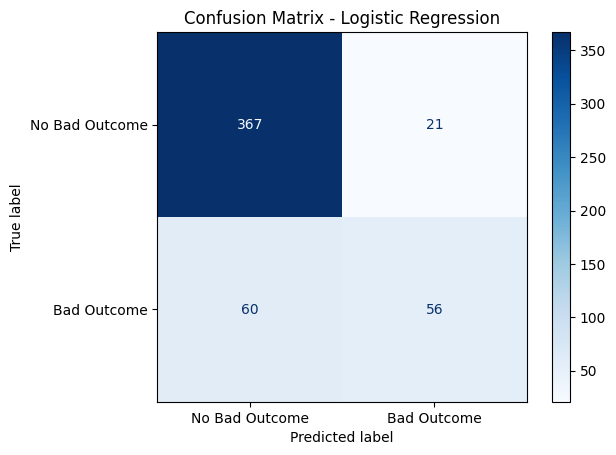

In [ ]:
# Output a confusion matrix to see performance
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=["No Bad Outcome", "Bad Outcome"],
    cmap=plt.cm.Blues)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

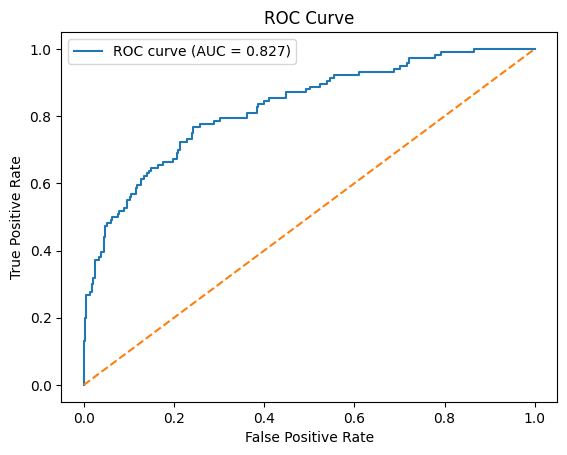

In [ ]:
# ROC-curve
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

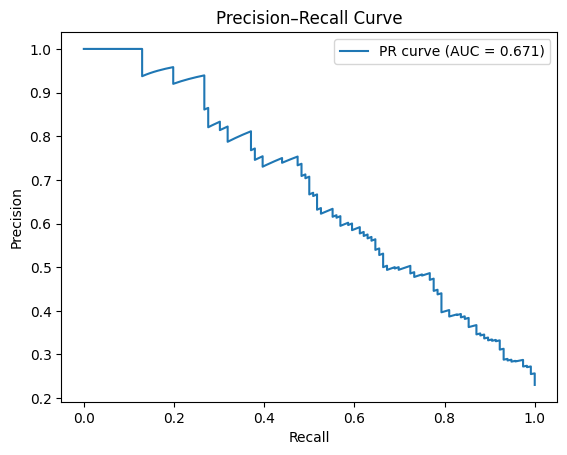

In [ ]:
# PR-AUC curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure()
plt.plot(recall, precision, label=f"PR curve (AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

| Class | Precision | Recall | F1-score | Support |
| ----- | --------- | ------ | -------- | ------- |
| 0     | 0.86      | 0.94   | 0.90     | 388     |
| 1     | 0.70      | 0.47   | 0.56     | 116     |


| Metric          | Value |
| --------------- | ----- |
| Accuracy        | 0.83  |
| Macro Avg F1    | 0.73  |
| Weighted Avg F1 | 0.82  |
| ROC-AUC         | 0.827 |
| PR-AUC          | 0.666 |


**Run logistic regression baseline model with scaling continuous features**

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("bin", "passthrough", binary_cols),
        ("cat", "passthrough", cat_cols),
    ]
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=3000)) # 3k worked last time, no class balancing just yet
]) # exclude class_weight="balanced"

X = df.drop(columns=["bad_outcome", "patientunitstayid"])
y = df["bad_outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.85      0.95      0.90       388
           1       0.73      0.46      0.56       116

    accuracy                           0.84       504
   macro avg       0.79      0.70      0.73       504
weighted avg       0.82      0.84      0.82       504

ROC-AUC: 0.8196542836829007
PR-AUC: 0.674187083971491


## Stacked Model Results

In [ ]:
# Base model A
apache_model = LogisticRegression(
    max_iter=1000, class_weight="balanced") # 80 70 without class weight balanced
apache_oof = get_oof_predictions(apache_model, X_apache, y)

# Base model B
pos_weight = (y == 0).sum() / (y == 1).sum()
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    random_state=42)

full_oof = get_oof_predictions(xgb_model, X_full, y)

# Meta dataset
meta_X = pd.DataFrame({
    "apache_risk": apache_oof,
    "full_model": full_oof})

# Build meta model
meta_model = LogisticRegression(max_iter=1000)

meta_oof = np.zeros(len(meta_X))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in skf.split(meta_X, y):
    X_train, X_val = meta_X.iloc[train_idx], meta_X.iloc[val_idx]
    y_train = y.iloc[train_idx]

    meta_model.fit(X_train, y_train)
    meta_oof[val_idx] = meta_model.predict_proba(X_val)[:, 1]

print("RAW STACKED AUC:", roc_auc_score(y, meta_oof))

y_pred = (meta_oof >= 0.5).astype(int)

print("\nCLASSIFICATION REPORT (RAW):\n")
print(classification_report(y, y_pred))

RAW STACKED AUC: 0.8181469187421759

CLASSIFICATION REPORT (RAW):

              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1938
           1       0.70      0.49      0.58       582

    accuracy                           0.83      2520
   macro avg       0.78      0.71      0.74      2520
weighted avg       0.82      0.83      0.82      2520



In [ ]:
# Isotonic calibration
iso_model = IsotonicRegression(out_of_bounds="clip")

iso_model.fit(meta_oof, y)

calibrated_probs = iso_model.transform(meta_oof)

print("CALIBRATED AUC:", roc_auc_score(y, calibrated_probs))

y_pred_cal = (calibrated_probs >= 0.5).astype(int)

print("\nCLASSIFICATION REPORT (CALIBRATED):\n")
print(classification_report(y, y_pred_cal))

CALIBRATED AUC: 0.8232257544001504

CLASSIFICATION REPORT (CALIBRATED):

              precision    recall  f1-score   support

           0       0.85      0.95      0.90      1938
           1       0.74      0.46      0.57       582

    accuracy                           0.84      2520
   macro avg       0.80      0.70      0.73      2520
weighted avg       0.83      0.84      0.82      2520



**LR + XGBoost + CatBoost + RF → Logistic Meta Learner Paper Strategy**

In [ ]:
target = "bad_outcome"
drop_cols = ["patientunitstayid", target]

X = df.drop(columns=drop_cols)
y = df[target]

def get_oof_predictions(model, X, y, n_splits=5):
    oof = np.zeros(len(X))

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y.iloc[train_idx]

        model.fit(X_train, y_train)
        oof[val_idx] = model.predict_proba(X_val)[:, 1]

    return oof

pos_weight = (y == 0).sum() / (y == 1).sum()

# RF model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42)

rf_oof = get_oof_predictions(rf_model, X, y)

# XGBoost Boosting Model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    random_state=42)

xgb_oof = get_oof_predictions(xgb_model, X, y)

# CatBoost Model
cat_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    verbose=0,
    random_seed=42)

cat_oof = get_oof_predictions(cat_model, X, y)

# Logistic regression baseline
lr_model = LogisticRegression(max_iter=3000, class_weight="balanced")
lr_oof = get_oof_predictions(lr_model, X, y)

# Meta
meta_X = pd.DataFrame({
    "rf": rf_oof,
    "xgb": xgb_oof,
    "cat": cat_oof,
    "lr": lr_oof})

# Metamodel stacking
meta_model = LogisticRegression(max_iter=3000)

meta_oof = np.zeros(len(meta_X))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in skf.split(meta_X, y):
    X_train, X_val = meta_X.iloc[train_idx], meta_X.iloc[val_idx]
    y_train = y.iloc[train_idx]

    meta_model.fit(X_train, y_train)
    meta_oof[val_idx] = meta_model.predict_proba(X_val)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
# Raw results
print("RAW STACKED AUC:", roc_auc_score(y, meta_oof))

y_pred = (meta_oof >= 0.5).astype(int)

print("\nCLASSIFICATION REPORT (RAW):\n")
print(classification_report(y, y_pred))

# Isotonic calibration
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(meta_oof, y)

calibrated = iso.transform(meta_oof)

# Final results
print("CALIBRATED AUC:", roc_auc_score(y, calibrated))

y_pred_cal = (calibrated >= 0.5).astype(int)

print("\nCLASSIFICATION REPORT (CALIBRATED):\n")
print(classification_report(y, y_pred_cal))

RAW STACKED AUC: 0.8276201419254625

CLASSIFICATION REPORT (RAW):

              precision    recall  f1-score   support

           0       0.85      0.95      0.90      1938
           1       0.73      0.45      0.55       582

    accuracy                           0.83      2520
   macro avg       0.79      0.70      0.73      2520
weighted avg       0.82      0.83      0.82      2520

CALIBRATED AUC: 0.8325677621383154

CLASSIFICATION REPORT (CALIBRATED):

              precision    recall  f1-score   support

           0       0.84      0.97      0.90      1938
           1       0.81      0.41      0.54       582

    accuracy                           0.84      2520
   macro avg       0.83      0.69      0.72      2520
weighted avg       0.84      0.84      0.82      2520



**XGBoost + CatBoost Combo**

In [ ]:
target = "bad_outcome"
drop_cols = ["patientunitstayid", target]

X = df.drop(columns=drop_cols)
y = df[target]

pos_weight = (y == 0).sum() / (y == 1).sum()
def get_oof_predictions(model, X, y, n_splits=5):
    oof = np.zeros(len(X))

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y.iloc[train_idx]

        model.fit(X_train, y_train)
        oof[val_idx] = model.predict_proba(X_val)[:, 1]

    return oof

# XGB base
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    random_state=42)

xgb_oof = get_oof_predictions(xgb_model, X, y)

# CatBoost base
cat_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    verbose=0,
    random_seed=42)

cat_oof = get_oof_predictions(cat_model, X, y)

# Meta
meta_X = pd.DataFrame({
    "xgb": xgb_oof,
    "cat": cat_oof})

# Meta model - logistic regression
meta_model = LogisticRegression(max_iter=1000)

meta_oof = np.zeros(len(meta_X))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in skf.split(meta_X, y):
    X_train, X_val = meta_X.iloc[train_idx], meta_X.iloc[val_idx]
    y_train = y.iloc[train_idx]

    meta_model.fit(X_train, y_train)
    meta_oof[val_idx] = meta_model.predict_proba(X_val)[:, 1]

# Calibrate
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(meta_oof, y)

calibrated_probs = iso.transform(meta_oof)

# Evaluate
print("CALIBRATED AUC:", roc_auc_score(y, calibrated_probs))

y_pred = (calibrated_probs >= 0.5).astype(int)

print(classification_report(y, y_pred))

CALIBRATED AUC: 0.8267464066473036
              precision    recall  f1-score   support

           0       0.83      0.98      0.90      1938
           1       0.87      0.35      0.50       582

    accuracy                           0.84      2520
   macro avg       0.85      0.67      0.70      2520
weighted avg       0.84      0.84      0.81      2520



**Comparing the 3 Combo Strategies**

| Model                                   | Calibrated AUC | Accuracy | Precision (Class 1) | Recall (Class 1) | F1-score (Class 1) | Key Behavior                                                 |
| --------------------------------------- | -------------- | -------- | ------------------- | ---------------- | ------------------ | ------------------------------------------------------------ |
| SEM Strategy (Paper-style stacking)     | 0.8237         | 0.84     | 0.90                | 0.33             | 0.48               | High precision, conservative predictions, misses many deaths |
| XGBoost + CatBoost                      | 0.8257         | 0.84     | 0.87                | 0.36             | 0.51               | Slightly better sensitivity, still conservative              |
| **LR + XGB + CAT + RF → Logistic Meta** | **0.8318**     | **0.84** | **0.80**            | **0.41**         | **0.54**           | Best overall balance, highest recall, best F1                |


**Best Model Metrics - LR + XGB + CAT + RF → Logistic Meta**

| Class | Precision | Recall | F1-score | Support |
| ----- | --------- | ------ | -------- | ------- |
| 0     | 0.85      | 0.97   | 0.90     | 1938    |
| 1     | 0.80      | 0.41   | 0.54     | 582     |

| Metric          | Value |
| --------------- | ----- |
| Accuracy        | 0.84  |
| Macro Avg F1    | 0.72  |
| Macro Avg Prec  | 0.82  |
| Macro Avg Recall| 0.69  |


**Fine-Tuning and Optimizing the Best Model**

In [ ]:
target = "bad_outcome"
drop_cols = ["patientunitstayid", target]

X = df.drop(columns=drop_cols)
y = df[target]

def get_oof_predictions(model, X, y, n_splits=5):
    oof = np.zeros(len(X))

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y.iloc[train_idx]

        model.fit(X_train, y_train)
        oof[val_idx] = model.predict_proba(X_val)[:, 1]

    return oof

pos_weight = (y == 0).sum() / (y == 1).sum()

# Base models
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    random_state=42)

cat_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    verbose=0,
    random_seed=42)

lr_model = LogisticRegression(max_iter=3000, class_weight="balanced")

rf_oof = get_oof_predictions(rf_model, X, y)
xgb_oof = get_oof_predictions(xgb_model, X, y)
cat_oof = get_oof_predictions(cat_model, X, y)
lr_oof = get_oof_predictions(lr_model, X, y)

# Meta data
meta_X = pd.DataFrame({
    "rf": rf_oof,
    "xgb": xgb_oof,
    "cat": cat_oof,
    "lr": lr_oof})

# Meta
meta_X = pd.DataFrame({
    "rf": rf_oof,
    "xgb": xgb_oof,
    "cat": cat_oof,
    "lr": lr_oof})

meta_model = LogisticRegression(max_iter=1000)

meta_oof = np.zeros(len(meta_X))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in skf.split(meta_X, y):
    X_train, X_val = meta_X.iloc[train_idx], meta_X.iloc[val_idx]
    y_train = y.iloc[train_idx]

    meta_model.fit(X_train, y_train)
    meta_oof[val_idx] = meta_model.predict_proba(X_val)[:, 1]

# Raw results
# print("RAW STACKED AUC:", roc_auc_score(y, meta_oof))
# y_pred = (meta_oof >= 0.5).astype(int)
# print("\nCLASSIFICATION REPORT (RAW):\n")
# print(classification_report(y, y_pred))

# Isotonic calibration
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(meta_oof, y)

calibrated = iso.transform(meta_oof)

# Final results - calibrated
print("CALIBRATED AUC:", roc_auc_score(y, calibrated))

y_pred_cal = (calibrated >= 0.5).astype(int)

print("\nCLASSIFICATION REPORT (CALIBRATED):\n")
print(classification_report(y, y_pred_cal))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

CALIBRATED AUC: 0.8325677621383154

CLASSIFICATION REPORT (CALIBRATED):

              precision    recall  f1-score   support

           0       0.84      0.97      0.90      1938
           1       0.81      0.41      0.54       582

    accuracy                           0.84      2520
   macro avg       0.83      0.69      0.72      2520
weighted avg       0.84      0.84      0.82      2520



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


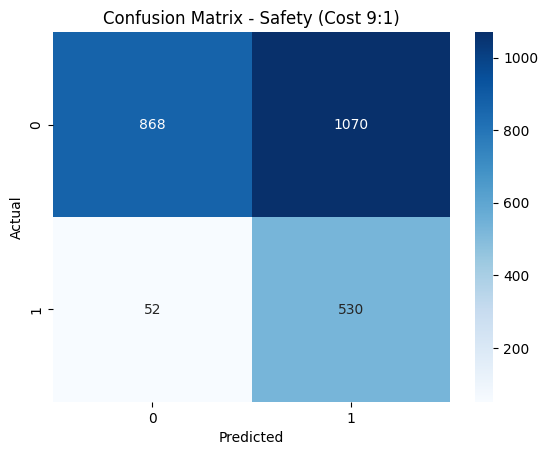

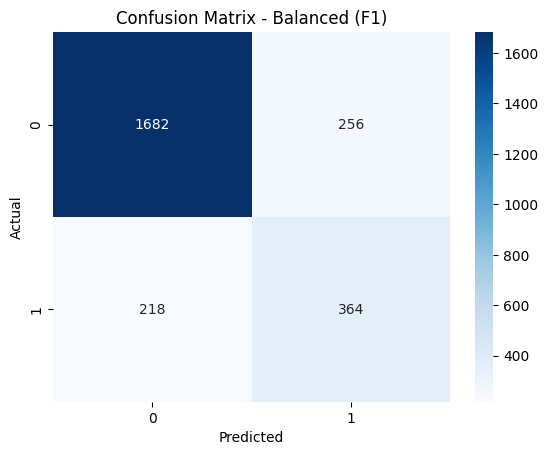

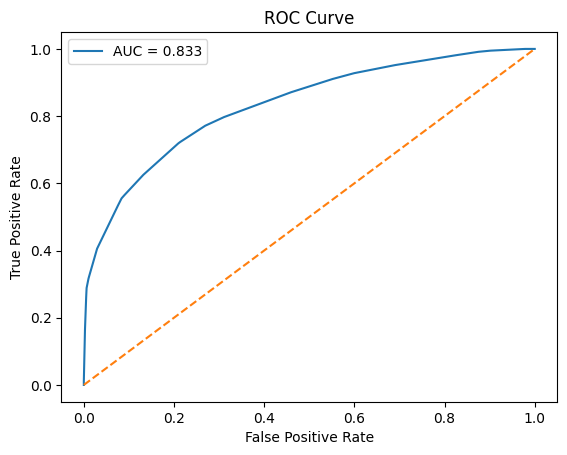

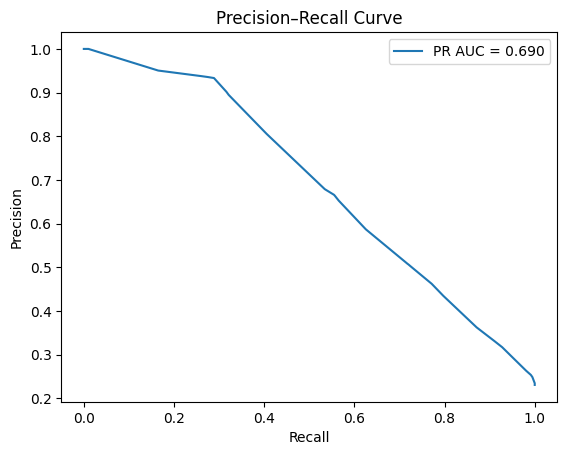

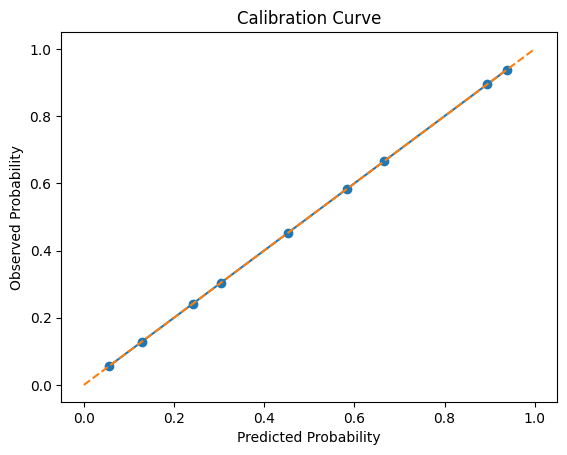

Raw Brier: 0.12109629597509013
Calibrated Brier: 0.11794796207148092


In [ ]:
# Thresholds
# t_cost = 0.138687 this is for 5:1
t_cost = 0.099091
t_f1 = 0.297071

models = {
    "Safety (Cost 9:1)": t_cost,
    "Balanced (F1)": t_f1}

# CONFUSION MATRIX
def plot_cm(t, title):
    preds = (calibrated >= t).astype(int)
    cm = confusion_matrix(y, preds)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ROC CURVE
def plot_roc():
    fpr, tpr, _ = roc_curve(y, calibrated)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

# PR CURVE
def plot_pr():
    precision, recall, _ = precision_recall_curve(y, calibrated)

    pr_auc = auc(recall, precision)

    plt.figure()
    plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve")
    plt.legend()
    plt.show()

# CALIBRATION CURVE
def plot_calibration():
    prob_true, prob_pred = calibration_curve(y, calibrated, n_bins=10)

    plt.figure()
    plt.plot(prob_pred, prob_true, marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Observed Probability")
    plt.title("Calibration Curve")
    plt.show()

# Run the plots
for name, t in models.items():
    plot_cm(t, name)

plot_roc()
plot_pr()
plot_calibration()

print("Raw Brier:", brier_score_loss(y, meta_oof))
print("Calibrated Brier:", brier_score_loss(y, calibrated))